## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import warnings 
warnings.filterwarnings('ignore')

## Load Dataset

In [3]:
df = pd.read_csv('Churn_Modelling.csv')

## Explore Dataset

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [41]:
df.shape

(10000, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [62]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Remove Unnecessary Columns

In [8]:
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## EDA

### Overall Churn Rate

In [12]:
# What percentage of customers left?
churn_rate = df['Exited'].value_counts(normalize=True)*100
print(churn_rate)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


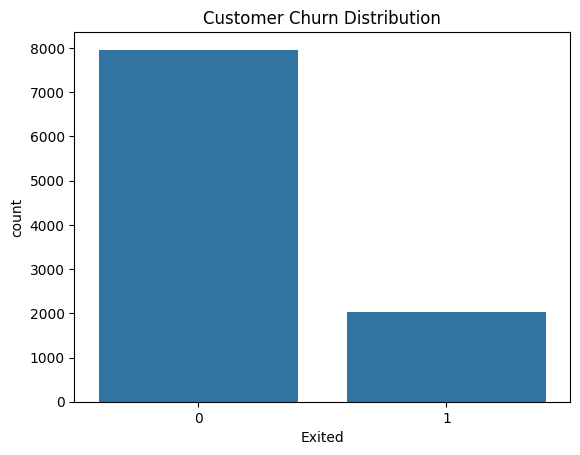

In [13]:
sns.countplot(x='Exited', data=df)
plt.title('Customer Churn Distribution')
plt.show()

### Churn by Gender

In [15]:
#Which gender has a higher churn rate?
gender_churn = pd.crosstab(df['Gender'], df['Exited'], normalize='index')*100
print(gender_churn)

Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928


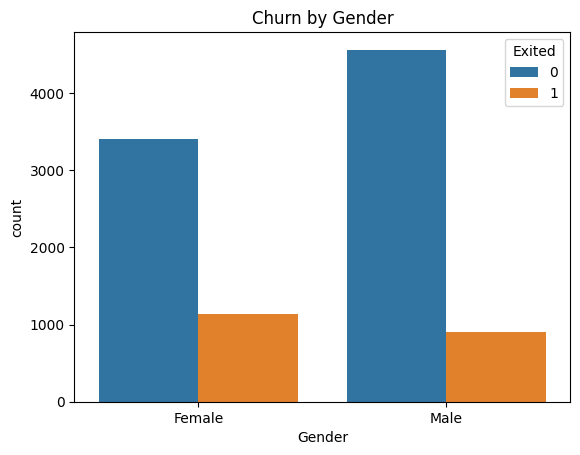

In [16]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title('Churn by Gender')
plt.show()

### Churn by Geography 

In [18]:
# Which country has the highest churn ?
geo_churn = pd.crosstab(df['Geography'], df['Exited'], normalize='index')*100
print(geo_churn)

Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


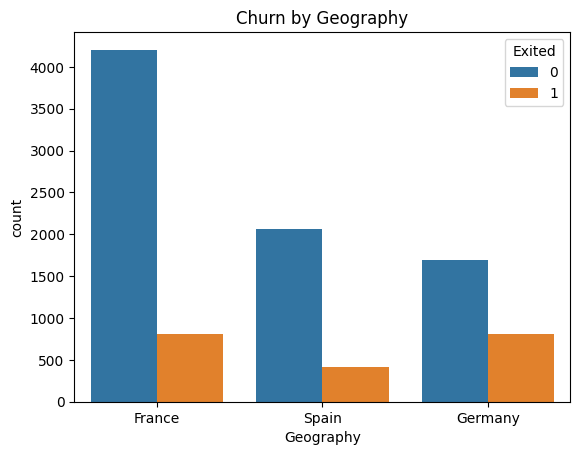

In [19]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Churn by Geography')
plt.show()

### Churn by Age 

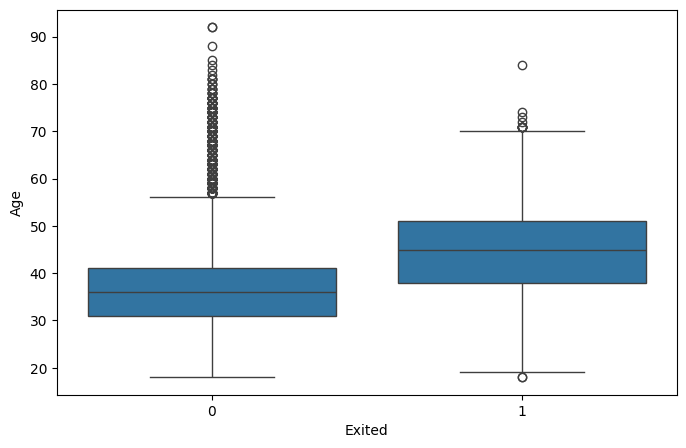

In [21]:
# Are churned customers older or younger?
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

In [22]:
df.groupby('Exited')['Age'].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

### Churn by Credit Score

In [23]:
# Does credit score affect churn?
df.groupby('Exited')['CreditScore'].mean()

Exited
0    651.853196
1    645.351497
Name: CreditScore, dtype: float64

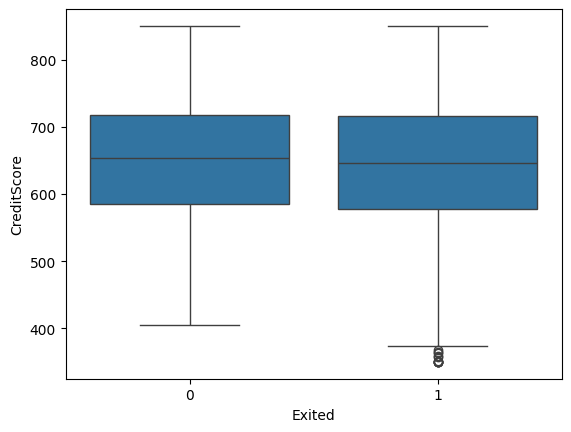

In [24]:
sns.boxplot(x='Exited', y='CreditScore', data=df)
plt.show()

### Churn by Account Balance

In [27]:
# Are customers with higher balances leaving more ?
df.groupby('Exited')['Balance'].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

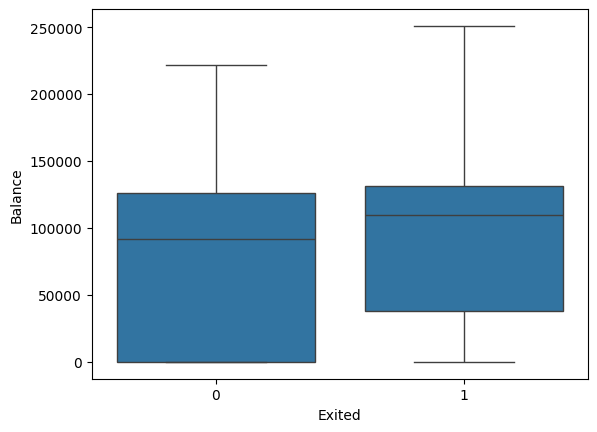

In [28]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

### Churn by Number of Products

In [30]:
# Which product category has the highest churn?
product_churn = pd.crosstab(df['NumOfProducts'],df['Exited'],normalize='index')*100
print(product_churn)

Exited                 0           1
NumOfProducts                       
1              72.285602   27.714398
2              92.418301    7.581699
3              17.293233   82.706767
4               0.000000  100.000000


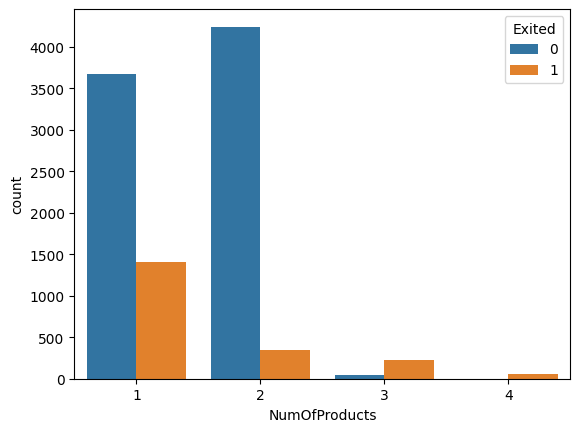

In [31]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.show()

### Churn by Active Member Status

In [35]:
# Are inactive customers more likely to leave?
active_churn = pd.crosstab(df['IsActiveMember'], df['Exited'],normalize='index')*100
print(active_churn)

Exited                  0          1
IsActiveMember                      
0               73.149103  26.850897
1               85.730926  14.269074


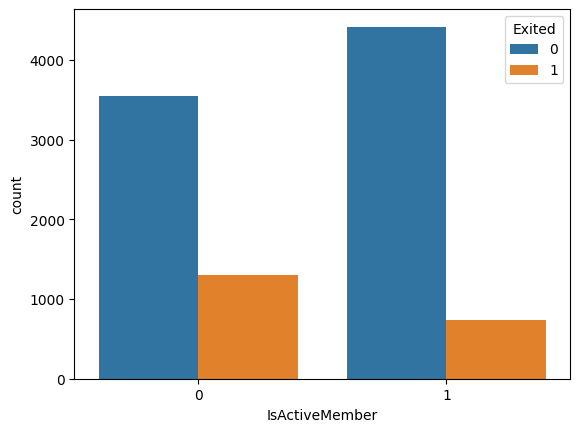

In [36]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.show()

### Churn by Tenure

In [37]:
# Do long-term customers churn less?
df.groupby('Exited')['Tenure'].mean()

Exited
0    5.033279
1    4.932744
Name: Tenure, dtype: float64

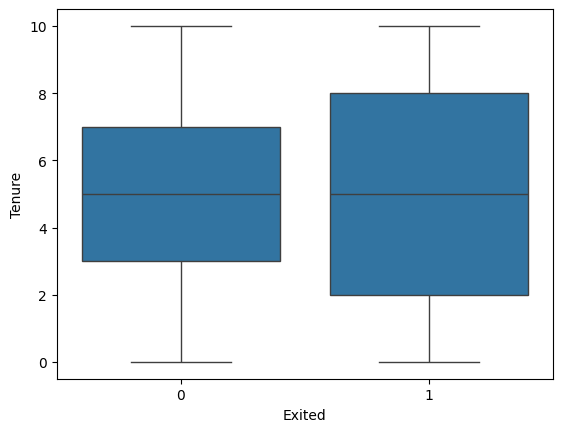

In [38]:
sns.boxplot(x='Exited', y='Tenure', data=df)
plt.show()

## Correlation Heatmap

In [39]:
# Which features have the strongest relationship with churn?
eda_df = df.copy()
le = LabelEncoder()
eda_df['Gender'] = le.fit_transform(eda_df['Gender'])
eda_df['Geography'] = le.fit_transform(eda_df['Geography'])

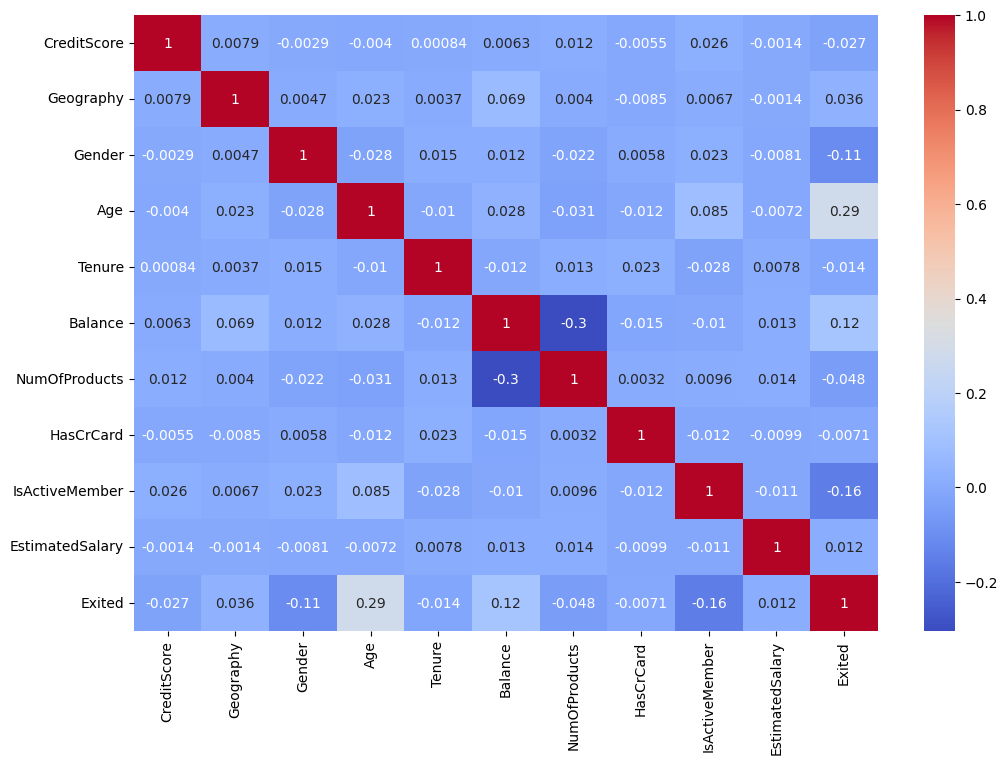

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(eda_df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Encoding

In [42]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [43]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

In [44]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## Define Features and Target

In [45]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [46]:
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


## Train-Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Feature Scaling

In [48]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [49]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

## Decision Tree

In [50]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

## Random Forest

In [51]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

## Compare Models

In [52]:
print("LR:", accuracy_score(y_test, lr_pred))
print("DT:", accuracy_score(y_test, dt_pred))
print("RF:", accuracy_score(y_test, rf_pred))

LR: 0.808
DT: 0.786
RF: 0.86


## Classification Report

In [53]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.76      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



## Confusion Matrix

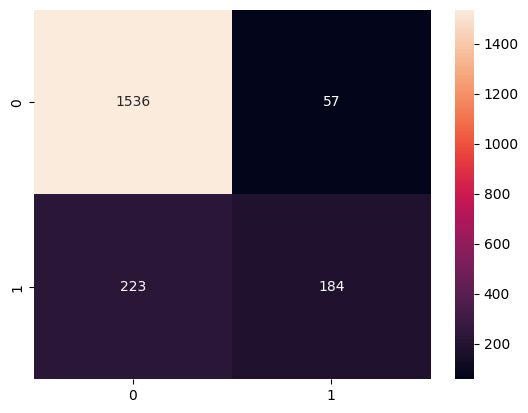

In [54]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## ROC-AUC Score

In [55]:
rf_probs = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test, rf_probs)

0.8558581694174915

## Feature Importance

In [56]:
print(X.columns)

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain'],
      dtype='str')


In [57]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

             Feature  Importance
2                Age    0.238625
8    EstimatedSalary    0.146702
4            Balance    0.143858
0        CreditScore    0.143468
5      NumOfProducts    0.124600
3             Tenure    0.080964
7     IsActiveMember    0.041910
9  Geography_Germany    0.028054
6          HasCrCard    0.019027
1             Gender    0.018573


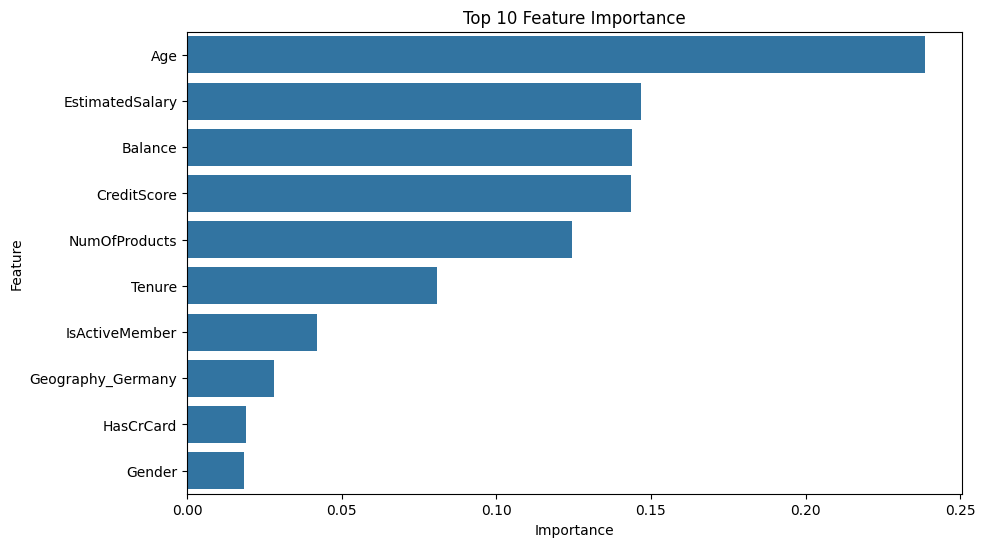

In [58]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title('Top 10 Feature Importance')
plt.show()

## Hyperparameter Tuning

In [59]:
from sklearn.model_selection import GridSearchCV

In [60]:
params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    params,
    cv=5
)
grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informatio